In [1]:
# ============================================================================
# ASYMMETRIC INTER-FRAGMENT RESIDUE CONTACT MATRICES
#
# Expected topology organization:
#   ACE + 16-residue peptide + NME
#
# Example:
#   1152 residues = 64 chains × 18 residues
#
# Contact definition:
#   For residue positions i and j, an A-chain/B-chain pair contributes one
#   contact event in a frame when at least one heavy-atom pair is within
#   the cutoff distance.
#
# Average contact count:
#   C_avg(i,j) = contact_event_counts(i,j) / N_frames
#
# Contact probability:
#   P(i,j) = contact_event_counts(i,j) /
#            (N_frames × N_fragment_A_copies × N_fragment_B_copies)
#
# Threshold:
#   If C_avg(i,j) < MIN_AVERAGE_CONTACTS:
#
#       C_avg(i,j) = 0
#       P(i,j)     = 0
#
# The matrices remain asymmetric:
#   rows    = Fragment A residues
#   columns = Fragment B residues
# ============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import MDAnalysis as mda

from MDAnalysis.lib.distances import capped_distance


# =============================================================================
# CONFIGURATION
# =============================================================================

CUTOFF = 5.0

CHAIN_LENGTH_WITH_CAPS = 18
CORE_LENGTH = 16

# Keep Fragment A × Fragment B direction.
# Do not average the matrix with its transpose.
SYMMETRIZE = False

# Values below 2 are converted to exact zero.
# Values equal to 2 are retained.
MIN_AVERAGE_CONTACTS = 2.0

OUTPUT_DIR = Path("contact_probability_matrices")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


SYSTEMS = [
    {
        "name": "frag4-7",

        "topology": Path(
            "frag4-7/out.center/"
            "prmtop.0d3_a_no_water_caprin.parm7"
        ),

        "trajectory": Path(
            "frag4-7/out.center/"
            "ctstep1.b.ns.nc"
        ),

        # Unique sequences are assigned according to first appearance
        # in the topology.
        "fragment_names": (
            "frag4",
            "frag7",
        ),
    },

    {
        "name": "frag7-10",

        "topology": Path(
            "frag7-10/out.center/"
            "prmtop.0d3_a_no_water_caprin.parm7"
        ),

        "trajectory": Path(
            "frag7-10/out.center/"
            "ctstep1.b.ns.nc"
        ),

        "fragment_names": (
            "frag7",
            "frag10",
        ),
    },
]


# =============================================================================
# CSV FORMATTING
# =============================================================================

def csv_float_format(value):
    """
    Write exact zero values as '0'.

    Nonzero floating-point values are written with eight decimal places.
    """
    if np.isclose(
        value,
        0.0,
        atol=1e-15,
    ):
        return "0"

    return f"{value:.8f}"


# =============================================================================
# PERIODIC BOX
# =============================================================================

def get_valid_box(ts):
    """
    Return valid periodic-box dimensions for the current frame.

    Returns None when box information is unavailable or invalid.
    """
    if ts.dimensions is None:
        return None

    box = np.asarray(
        ts.dimensions,
        dtype=np.float32,
    )

    if box.shape != (6,):
        return None

    if not np.all(
        np.isfinite(box)
    ):
        return None

    if np.any(
        box[:3] <= 0
    ):
        return None

    return box


# =============================================================================
# SPLIT CAPPED PEPTIDE CHAINS
# =============================================================================

def split_capped_chains(
    universe,
    chain_length=18,
    core_length=16,
):
    """
    Split globally numbered Amber residues into capped peptide chains.

    Each chain is expected to contain:

        ACE + 16 core residues + NME
    """
    all_residues = universe.residues
    n_total_residues = len(
        all_residues
    )

    if (
        n_total_residues
        % chain_length
        != 0
    ):
        raise ValueError(
            f"The topology contains "
            f"{n_total_residues} residues, "
            f"which is not divisible by the expected "
            f"chain length of {chain_length}."
        )

    n_chains = (
        n_total_residues
        // chain_length
    )

    chains = []

    for chain_index in range(
        n_chains
    ):
        start = (
            chain_index
            * chain_length
        )

        stop = (
            start
            + chain_length
        )

        block = all_residues[
            start:stop
        ]

        first_name = (
            block[0]
            .resname
            .upper()
        )

        last_name = (
            block[-1]
            .resname
            .upper()
        )

        if (
            first_name != "ACE"
            or last_name != "NME"
        ):
            block_description = [
                f"{residue.resname}"
                f"{residue.resid}"
                for residue in block
            ]

            raise ValueError(
                f"Chain block {chain_index + 1} "
                f"does not begin with ACE and end with NME.\n"
                f"Detected block:\n"
                f"{block_description}"
            )

        # Remove ACE and NME.
        core = block[1:-1]

        if len(core) != core_length:
            raise ValueError(
                f"Chain {chain_index + 1} contains "
                f"{len(core)} core residues instead of "
                f"{core_length}."
            )

        chains.append(
            core
        )

    return chains


# =============================================================================
# GROUP CHAINS BY SEQUENCE
# =============================================================================

def group_chains_by_sequence(
    chains,
):
    """
    Group peptide copies according to their 16-residue sequence.

    Dictionary order follows first appearance in the topology.
    """
    sequence_groups = {}

    for chain in chains:
        signature = tuple(
            residue.resname.upper()
            for residue in chain
        )

        if signature not in sequence_groups:
            sequence_groups[
                signature
            ] = []

        sequence_groups[
            signature
        ].append(
            chain
        )

    return sequence_groups


def print_sequence_information(
    sequence_groups,
    fragment_names,
):
    """
    Print detected sequences and numbers of peptide copies.
    """
    print(
        "\nDetected fragment sequences:"
    )

    for index, (
        signature,
        chains,
    ) in enumerate(
        sequence_groups.items()
    ):
        if index < len(
            fragment_names
        ):
            fragment_name = (
                fragment_names[index]
            )
        else:
            fragment_name = (
                f"sequence_{index + 1}"
            )

        sequence_text = "-".join(
            signature
        )

        print(
            f"  {fragment_name}: "
            f"{len(chains)} copies\n"
            f"    {sequence_text}"
        )


# =============================================================================
# HEAVY-ATOM GROUPS
# =============================================================================

def heavy_atom_indices(
    residue,
):
    """
    Return heavy-atom indices for one residue.
    """
    atoms = residue.atoms

    # Amber topology normally provides atomic masses.
    heavy_atoms = atoms[
        atoms.masses > 1.5
    ]

    if len(heavy_atoms) == 0:
        # Fallback based on Amber atom names.
        heavy_atoms = (
            atoms.select_atoms(
                "not name H*"
            )
        )

    if len(heavy_atoms) == 0:
        raise ValueError(
            f"No heavy atoms were found for "
            f"{residue.resname}"
            f"{residue.resid}."
        )

    return heavy_atoms.indices


def build_position_atomgroups(
    universe,
    fragment_chains,
    core_length=16,
):
    """
    Combine heavy atoms from all peptide copies at each local position.

    Returns
    -------
    atomgroups
        One MDAnalysis AtomGroup for each local residue position.

    owners
        For every atom in an AtomGroup, the index of the peptide copy
        that owns that atom.
    """
    atomgroups = []
    owners = []

    for local_position in range(
        core_length
    ):
        position_atom_indices = []
        position_owners = []

        for chain_index, chain in enumerate(
            fragment_chains
        ):
            residue = chain[
                local_position
            ]

            indices = heavy_atom_indices(
                residue
            )

            position_atom_indices.extend(
                indices.tolist()
            )

            position_owners.extend(
                [chain_index]
                * len(indices)
            )

        position_atom_indices = np.asarray(
            position_atom_indices,
            dtype=np.int64,
        )

        position_owners = np.asarray(
            position_owners,
            dtype=np.int32,
        )

        atomgroups.append(
            universe.atoms[
                position_atom_indices
            ]
        )

        owners.append(
            position_owners
        )

    return atomgroups, owners


# =============================================================================
# RESIDUE LABELS
# =============================================================================

def local_residue_labels(
    representative_chain,
    fragment_name,
):
    """
    Generate labels such as:

        frag4_GLY1
        frag4_PHE2
        frag4_ARG3
    """
    return [
        (
            f"{fragment_name}_"
            f"{residue.resname}"
            f"{position + 1}"
        )
        for position, residue in enumerate(
            representative_chain
        )
    ]


# =============================================================================
# MAIN CALCULATION
# =============================================================================

def calculate_interfragment_contacts(
    topology_path,
    trajectory_path,
    fragment_names,
    cutoff=5.0,
    core_length=16,
    minimum_average_contacts=2.0,
    symmetrize=False,
):
    """
    Calculate asymmetric inter-fragment contact matrices.

    Each A-chain/B-chain pair contributes at most one contact event
    for residue positions (i,j) in a frame, regardless of how many
    heavy-atom pairs are within the cutoff.

    The average-contact threshold is applied before exporting matrices.

    If average_contact_count(i,j) < minimum_average_contacts:

        average_contact_count(i,j) = 0
        probability(i,j)           = 0
        total_contact_events(i,j)  = 0
    """

    if not topology_path.exists():
        raise FileNotFoundError(
            f"Topology file was not found:\n"
            f"{topology_path.resolve()}"
        )

    if not trajectory_path.exists():
        raise FileNotFoundError(
            f"Trajectory file was not found:\n"
            f"{trajectory_path.resolve()}"
        )

    print(
        "\n"
        + "=" * 78
    )

    print(
        f"Loading trajectory: "
        f"{trajectory_path}"
    )

    universe = mda.Universe(
        str(topology_path),
        str(trajectory_path),
    )

    chains = split_capped_chains(
        universe=universe,
        chain_length=CHAIN_LENGTH_WITH_CAPS,
        core_length=core_length,
    )

    print(
        f"Total topology residues: "
        f"{len(universe.residues)}"
    )

    print(
        f"Total capped chains:     "
        f"{len(chains)}"
    )

    print(
        f"Core residues per chain: "
        f"{core_length}"
    )

    sequence_groups = (
        group_chains_by_sequence(
            chains
        )
    )

    print_sequence_information(
        sequence_groups=sequence_groups,
        fragment_names=fragment_names,
    )

    if len(sequence_groups) != 2:
        detected_sequences = [
            "-".join(sequence)
            for sequence
            in sequence_groups
        ]

        raise ValueError(
            f"Expected exactly two unique "
            f"{core_length}-residue sequences, "
            f"but detected {len(sequence_groups)}.\n"
            f"Detected sequences:\n"
            f"{detected_sequences}"
        )

    grouped_chains = list(
        sequence_groups.values()
    )

    fragment_a_chains = (
        grouped_chains[0]
    )

    fragment_b_chains = (
        grouped_chains[1]
    )

    fragment_a_name = (
        fragment_names[0]
    )

    fragment_b_name = (
        fragment_names[1]
    )

    n_a = len(
        fragment_a_chains
    )

    n_b = len(
        fragment_b_chains
    )

    if n_a == 0 or n_b == 0:
        raise ValueError(
            "One of the detected fragment groups "
            "contains no peptide copies."
        )

    n_chain_pair_opportunities = (
        n_a * n_b
    )

    print(
        f"\nCalculating contacts between "
        f"{n_a} copies of {fragment_a_name} and "
        f"{n_b} copies of {fragment_b_name}."
    )

    print(
        f"Chain-pair opportunities per frame: "
        f"{n_chain_pair_opportunities}"
    )

    print(
        f"Average-contact threshold: "
        f"{minimum_average_contacts:g}"
    )

    print(
        "Matrices will remain asymmetric."
        if not symmetrize
        else "Matrices will be symmetrized."
    )

    # ------------------------------------------------------------------------
    # Build combined heavy-atom groups once.
    # ------------------------------------------------------------------------

    (
        a_atomgroups,
        a_owners,
    ) = build_position_atomgroups(
        universe=universe,
        fragment_chains=fragment_a_chains,
        core_length=core_length,
    )

    (
        b_atomgroups,
        b_owners,
    ) = build_position_atomgroups(
        universe=universe,
        fragment_chains=fragment_b_chains,
        core_length=core_length,
    )

    # Total chain-pair/frame contact events.
    contact_event_counts = np.zeros(
        (
            core_length,
            core_length,
        ),
        dtype=np.int64,
    )

    n_frames = 0

    # ------------------------------------------------------------------------
    # Process trajectory frames.
    # ------------------------------------------------------------------------

    for ts in universe.trajectory:
        n_frames += 1

        box = get_valid_box(
            ts
        )

        for i in range(
            core_length
        ):
            positions_a = (
                a_atomgroups[i]
                .positions
            )

            owners_a = (
                a_owners[i]
            )

            for j in range(
                core_length
            ):
                positions_b = (
                    b_atomgroups[j]
                    .positions
                )

                owners_b = (
                    b_owners[j]
                )

                # Find all heavy-atom pairs within the cutoff.
                atom_pairs = capped_distance(
                    reference=positions_a,
                    configuration=positions_b,
                    max_cutoff=cutoff,
                    box=box,
                    return_distances=False,
                )

                if atom_pairs.size == 0:
                    continue

                # Determine which peptide-copy pair owns each atom contact.
                chain_a_ids = owners_a[
                    atom_pairs[:, 0]
                ]

                chain_b_ids = owners_b[
                    atom_pairs[:, 1]
                ]

                # Unique integer ID for every A-chain/B-chain pair.
                chain_pair_ids = (
                    chain_a_ids.astype(
                        np.int64
                    )
                    * n_b
                    + chain_b_ids.astype(
                        np.int64
                    )
                )

                # Multiple heavy-atom contacts from the same chain pair
                # count as one residue-pair contact event in this frame.
                number_of_contacting_chain_pairs = (
                    np.unique(
                        chain_pair_ids
                    ).size
                )

                contact_event_counts[
                    i,
                    j,
                ] += (
                    number_of_contacting_chain_pairs
                )

        if n_frames % 100 == 0:
            print(
                f"Processed "
                f"{n_frames} frames"
            )

    if n_frames == 0:
        raise RuntimeError(
            f"No frames were read from "
            f"{trajectory_path}."
        )

    # ------------------------------------------------------------------------
    # Calculate unfiltered matrices.
    # ------------------------------------------------------------------------

    unfiltered_average_contact_count = (
        contact_event_counts.astype(
            np.float64
        )
        / float(n_frames)
    )

    unfiltered_average_contact_count = np.clip(
        unfiltered_average_contact_count,
        0.0,
        float(
            n_chain_pair_opportunities
        ),
    )

    probability_denominator = float(
        n_frames
        * n_chain_pair_opportunities
    )

    unfiltered_probability = (
        contact_event_counts.astype(
            np.float64
        )
        / probability_denominator
    )

    unfiltered_probability = np.clip(
        unfiltered_probability,
        0.0,
        1.0,
    )

    # ------------------------------------------------------------------------
    # Apply threshold.
    #
    # Average contact values exactly equal to the threshold are retained.
    # ------------------------------------------------------------------------

    keep_mask = (
        unfiltered_average_contact_count
        >= minimum_average_contacts
    )

    filtered_average_contact_count = np.where(
        keep_mask,
        unfiltered_average_contact_count,
        0.0,
    )

    filtered_probability = np.where(
        keep_mask,
        unfiltered_probability,
        0.0,
    )

    filtered_contact_event_counts = np.where(
        keep_mask,
        contact_event_counts,
        0,
    ).astype(
        np.int64
    )

    number_cells_retained = int(
        np.count_nonzero(
            keep_mask
        )
    )

    number_cells_removed = int(
        keep_mask.size
        - number_cells_retained
    )

    # ------------------------------------------------------------------------
    # Optional symmetrization.
    #
    # This remains disabled for inter-fragment matrices by default.
    # ------------------------------------------------------------------------

    if symmetrize:
        filtered_average_contact_count = (
            0.5
            * (
                filtered_average_contact_count
                + filtered_average_contact_count.T
            )
        )

        filtered_probability = (
            0.5
            * (
                filtered_probability
                + filtered_probability.T
            )
        )

        # Reapply the threshold after symmetrization.
        final_keep_mask = (
            filtered_average_contact_count
            >= minimum_average_contacts
        )

        filtered_average_contact_count = np.where(
            final_keep_mask,
            filtered_average_contact_count,
            0.0,
        )

        filtered_probability = np.where(
            final_keep_mask,
            filtered_probability,
            0.0,
        )

        # Event counts are not meaningfully averaged into integers.
        # Retain counts only where the final matrix passes the threshold.
        filtered_contact_event_counts = np.where(
            final_keep_mask,
            filtered_contact_event_counts,
            0,
        ).astype(
            np.int64
        )

    # ------------------------------------------------------------------------
    # Final numeric ranges.
    # ------------------------------------------------------------------------

    filtered_average_contact_count = np.clip(
        filtered_average_contact_count,
        0.0,
        float(
            n_chain_pair_opportunities
        ),
    )

    filtered_probability = np.clip(
        filtered_probability,
        0.0,
        1.0,
    )

    # ------------------------------------------------------------------------
    # Residue labels.
    # ------------------------------------------------------------------------

    row_labels = local_residue_labels(
        representative_chain=fragment_a_chains[0],
        fragment_name=fragment_a_name,
    )

    column_labels = local_residue_labels(
        representative_chain=fragment_b_chains[0],
        fragment_name=fragment_b_name,
    )

    # ------------------------------------------------------------------------
    # DataFrames.
    # ------------------------------------------------------------------------

    probability_df = pd.DataFrame(
        filtered_probability,
        index=row_labels,
        columns=column_labels,
    )

    average_contact_count_df = pd.DataFrame(
        filtered_average_contact_count,
        index=row_labels,
        columns=column_labels,
    )

    contact_event_counts_df = pd.DataFrame(
        filtered_contact_event_counts,
        index=row_labels,
        columns=column_labels,
    )

    threshold_mask_df = pd.DataFrame(
        keep_mask.astype(
            np.int8
        ),
        index=row_labels,
        columns=column_labels,
    )

    # Optional unfiltered DataFrames for auditing.
    unfiltered_probability_df = pd.DataFrame(
        unfiltered_probability,
        index=row_labels,
        columns=column_labels,
    )

    unfiltered_average_contact_count_df = pd.DataFrame(
        unfiltered_average_contact_count,
        index=row_labels,
        columns=column_labels,
    )

    information = {
        "n_frames": n_frames,

        "n_fragment_a": n_a,
        "n_fragment_b": n_b,

        "n_chain_pairs": (
            n_chain_pair_opportunities
        ),

        "fragment_a": (
            fragment_a_name
        ),

        "fragment_b": (
            fragment_b_name
        ),

        "minimum_average_contact_threshold": (
            minimum_average_contacts
        ),

        "number_cells_retained": (
            number_cells_retained
        ),

        "number_cells_removed": (
            number_cells_removed
        ),

        "minimum_probability": float(
            filtered_probability.min()
        ),

        "maximum_probability": float(
            filtered_probability.max()
        ),

        "minimum_average_contact_count": float(
            filtered_average_contact_count.min()
        ),

        "maximum_average_contact_count": float(
            filtered_average_contact_count.max()
        ),

        "total_contact_events_before_filter": int(
            contact_event_counts.sum()
        ),

        "total_contact_events_after_filter": int(
            filtered_contact_event_counts.sum()
        ),
    }

    return (
        probability_df,
        average_contact_count_df,
        contact_event_counts_df,
        threshold_mask_df,
        unfiltered_probability_df,
        unfiltered_average_contact_count_df,
        information,
    )


# =============================================================================
# PROCESS ALL TRAJECTORIES
# =============================================================================

summary_rows = []

for system in SYSTEMS:

    (
        probability_df,
        average_contact_count_df,
        contact_event_counts_df,
        threshold_mask_df,
        unfiltered_probability_df,
        unfiltered_average_contact_count_df,
        info,
    ) = calculate_interfragment_contacts(
        topology_path=system["topology"],
        trajectory_path=system["trajectory"],
        fragment_names=system["fragment_names"],
        cutoff=CUTOFF,
        core_length=CORE_LENGTH,
        minimum_average_contacts=MIN_AVERAGE_CONTACTS,
        symmetrize=SYMMETRIZE,
    )

    # ------------------------------------------------------------------------
    # Filtered asymmetric probability matrix.
    # ------------------------------------------------------------------------

    probability_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_Raw_Matrix.csv"
    )

    probability_df.to_csv(
        probability_output_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    # Compatibility filename.
    #
    # Because SYMMETRIZE=False, this file is identical to Raw_Matrix.csv.
    probability_compatibility_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_Matrix.csv"
    )

    probability_df.to_csv(
        probability_compatibility_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    # ------------------------------------------------------------------------
    # Filtered asymmetric average-contact-count matrix.
    # ------------------------------------------------------------------------

    average_count_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Average_Contact_Count_Raw_Matrix.csv"
    )

    average_contact_count_df.to_csv(
        average_count_output_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    # Compatibility filename.
    #
    # Because SYMMETRIZE=False, this is identical to the raw matrix.
    average_count_compatibility_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Average_Contact_Count_Matrix.csv"
    )

    average_contact_count_df.to_csv(
        average_count_compatibility_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    # ------------------------------------------------------------------------
    # Filtered total event counts.
    # ------------------------------------------------------------------------

    total_counts_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Total_Contact_Events.csv"
    )

    contact_event_counts_df.to_csv(
        total_counts_output_csv,
        index=True,
        index_label="Residue",
    )

    # ------------------------------------------------------------------------
    # Threshold mask:
    #
    # 1 = retained
    # 0 = removed because average contact count < 2
    # ------------------------------------------------------------------------

    threshold_mask_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Threshold_Mask.csv"
    )

    threshold_mask_df.to_csv(
        threshold_mask_output_csv,
        index=True,
        index_label="Residue",
    )

    # ------------------------------------------------------------------------
    # Optional unfiltered audit files.
    #
    # These preserve values before applying the average-contact threshold.
    # ------------------------------------------------------------------------

    unfiltered_probability_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Probability_Unfiltered.csv"
    )

    unfiltered_probability_df.to_csv(
        unfiltered_probability_output_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    unfiltered_average_output_csv = OUTPUT_DIR / (
        f"{system['name']}-"
        f"Residue_Residue_5A_"
        f"Average_Contact_Count_Unfiltered.csv"
    )

    unfiltered_average_contact_count_df.to_csv(
        unfiltered_average_output_csv,
        index=True,
        index_label="Residue",
        float_format=csv_float_format,
    )

    # ------------------------------------------------------------------------
    # Summary.
    # ------------------------------------------------------------------------

    summary_rows.append(
        {
            "system": (
                system["name"]
            ),

            "frames": (
                info["n_frames"]
            ),

            "fragment_A_copies": (
                info["n_fragment_a"]
            ),

            "fragment_B_copies": (
                info["n_fragment_b"]
            ),

            "chain_pairs_per_frame": (
                info["n_chain_pairs"]
            ),

            "minimum_average_threshold": (
                info[
                    "minimum_average_contact_threshold"
                ]
            ),

            "cells_retained": (
                info[
                    "number_cells_retained"
                ]
            ),

            "cells_removed": (
                info[
                    "number_cells_removed"
                ]
            ),

            "maximum_probability": (
                info[
                    "maximum_probability"
                ]
            ),

            "maximum_average_contacts": (
                info[
                    "maximum_average_contact_count"
                ]
            ),

            "events_before_filter": (
                info[
                    "total_contact_events_before_filter"
                ]
            ),

            "events_after_filter": (
                info[
                    "total_contact_events_after_filter"
                ]
            ),

            "probability_output": str(
                probability_output_csv
            ),

            "average_count_output": str(
                average_count_output_csv
            ),
        }
    )

    print(
        "\nCompleted:"
    )

    print(
        f"  System:                      "
        f"{system['name']}"
    )

    print(
        f"  Frames:                      "
        f"{info['n_frames']}"
    )

    print(
        f"  Fragment A copies:           "
        f"{info['n_fragment_a']}"
    )

    print(
        f"  Fragment B copies:           "
        f"{info['n_fragment_b']}"
    )

    print(
        f"  Chain pairs per frame:       "
        f"{info['n_chain_pairs']}"
    )

    print(
        f"  Matrix shape:                "
        f"{probability_df.shape}"
    )

    print(
        f"  Minimum average threshold:   "
        f"{info['minimum_average_contact_threshold']:.2f}"
    )

    print(
        f"  Residue-pair cells retained: "
        f"{info['number_cells_retained']}"
    )

    print(
        f"  Residue-pair cells removed:  "
        f"{info['number_cells_removed']}"
    )

    print(
        f"  Probability range:           "
        f"{probability_df.values.min():.8f} to "
        f"{probability_df.values.max():.8f}"
    )

    print(
        f"  Average contact range:       "
        f"{average_contact_count_df.values.min():.8f} to "
        f"{average_contact_count_df.values.max():.8f}"
    )

    print(
        f"  Events before filtering:     "
        f"{info['total_contact_events_before_filter']}"
    )

    print(
        f"  Events after filtering:      "
        f"{info['total_contact_events_after_filter']}"
    )

    print(
        f"  Probability matrix:          "
        f"{probability_output_csv}"
    )

    print(
        f"  Average contact matrix:      "
        f"{average_count_output_csv}"
    )

    print(
        f"  Threshold mask:              "
        f"{threshold_mask_output_csv}"
    )


# =============================================================================
# FINAL PROCESSING SUMMARY
# =============================================================================

summary_df = pd.DataFrame(
    summary_rows
)

print(
    "\n"
    + "=" * 78
)

print(
    "Processing summary"
)

print(
    "=" * 78
)

print(
    summary_df.to_string(
        index=False
    )
)


Loading trajectory: frag4-7/out.center/ctstep1.b.ns.nc
Total topology residues: 1152
Total capped chains:     64
Core residues per chain: 16

Detected fragment sequences:
  frag4: 32 copies
    GLY-PHE-ARG-GLY-GLY-TYR-ASP-GLY-TYR-ARG-PRO-SER-PHE-SER-ASN-THR
  frag7: 32 copies
    GLN-PHE-SER-ALA-PRO-ARG-ASP-TYR-SER-GLY-TYR-GLN-ARG-ASP-GLY-TYR

Calculating contacts between 32 copies of frag4 and 32 copies of frag7.
Chain-pair opportunities per frame: 1024
Average-contact threshold: 2
Matrices will remain asymmetric.
Processed 100 frames
Processed 200 frames
Processed 300 frames
Processed 400 frames
Processed 500 frames
Processed 600 frames
Processed 700 frames
Processed 800 frames

Completed:
  System:                      frag4-7
  Frames:                      891
  Fragment A copies:           32
  Fragment B copies:           32
  Chain pairs per frame:       1024
  Matrix shape:                (16, 16)
  Minimum average threshold:   2.00
  Residue-pair cells retained: 175
  Residue

frag4-7    | shape = (16, 16) | maximum asymmetry = 0.008681 | minimum = 0.000000 | maximum = 0.010987 | nonzero cells = 175
  Y-axis (Fragment 4): G F R G G Y D G Y R P S F S N T
  X-axis (Fragment 7): Q F S A P R D Y S G Y Q R D G Y
frag7-10   | shape = (16, 16) | maximum asymmetry = 0.008563 | minimum = 0.000000 | maximum = 0.008563 | nonzero cells = 134
  Y-axis (Fragment 7): G Q S G P R G A P R G R G G P P
  X-axis (Fragment 10): Q F S A P R D Y S G Y Q R D G Y

Shared color maximum: 0.010987

Saved PNG: asymmetric_contact_map_plots/frag4-7_asymmetric_contact_map.png
Saved PDF: asymmetric_contact_map_plots/frag4-7_asymmetric_contact_map.pdf
Saved SVG: asymmetric_contact_map_plots/frag4-7_asymmetric_contact_map.svg


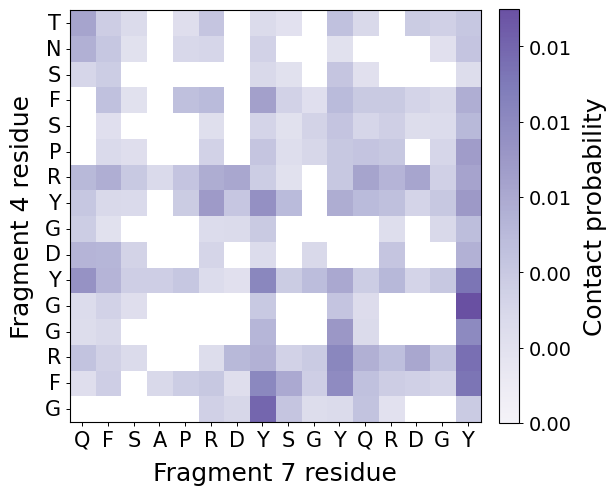


Saved PNG: asymmetric_contact_map_plots/frag7-10_asymmetric_contact_map.png
Saved PDF: asymmetric_contact_map_plots/frag7-10_asymmetric_contact_map.pdf
Saved SVG: asymmetric_contact_map_plots/frag7-10_asymmetric_contact_map.svg


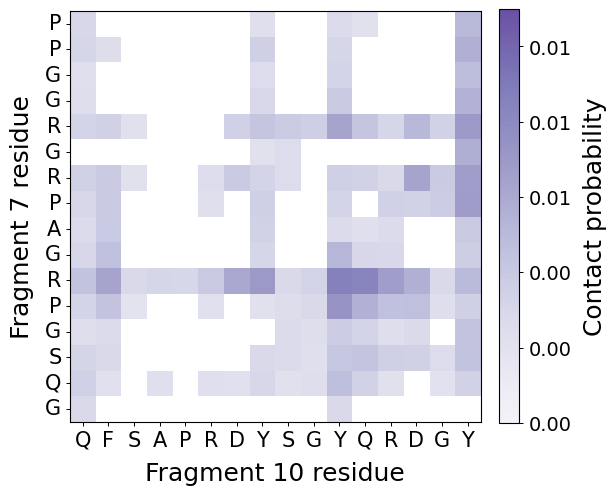

In [8]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import FormatStrFormatter


# =============================================================================
# CONFIGURATION
# =============================================================================

DIR = Path("contact_probability_matrices")

SYSTEMS = {
    "frag4-7": {
        # Raw, asymmetric Fragment 4 × Fragment 7 probability matrix
        "csv": DIR / "frag4-7-Residue_Residue_5A_Raw_Matrix.csv",
        "row_fragment": "Fragment 4",
        "column_fragment": "Fragment 7",
    },

    "frag7-10": {
        # Raw, asymmetric Fragment 7 × Fragment 10 probability matrix
        "csv": DIR / "frag7-10-Residue_Residue_5A_Raw_Matrix.csv",
        "row_fragment": "Fragment 7",
        "column_fragment": "Fragment 10",
    },
}

EXPECTED_MATRIX_SIZE = 16

# Preserve the original inter-fragment matrix.
SYMMETRIZE = None

# Do not remove diagonal positions.
#
# For example, cell (5,5) is:
# Fragment-A residue 5 contacting Fragment-B residue 5.
# It is not self-contact.
ZERO_DIAGONAL = False

MASK_ZERO_VALUES = True

# Same color scale for both maps.
SHARED_SCALE = True

OUT_DIR = Path("asymmetric_contact_map_plots")

DPI = 600
SAVE_PDF = True
SAVE_SVG = True

CMAP_BASE = "Purples"
CMAP_MIN = 0.08
CMAP_MAX = 0.75

VMAX_PERCENTILE = 100.0


# =============================================================================
# AMINO-ACID LABELS
# =============================================================================

THREE_TO_ONE = {
    "ALA": "A",
    "ARG": "R",
    "ASN": "N",
    "ASP": "D",
    "CYS": "C",
    "GLN": "Q",
    "GLU": "E",
    "GLY": "G",
    "HIS": "H",
    "ILE": "I",
    "LEU": "L",
    "LYS": "K",
    "MET": "M",
    "PHE": "F",
    "PRO": "P",
    "SER": "S",
    "THR": "T",
    "TRP": "W",
    "TYR": "Y",
    "VAL": "V",
}

RESIDUE_PATTERN = re.compile(
    r"(ALA|ARG|ASN|ASP|CYS|GLN|GLU|GLY|HIS|ILE|"
    r"LEU|LYS|MET|PHE|PRO|SER|THR|TRP|TYR|VAL)"
)


# =============================================================================
# PUBLICATION STYLE
# =============================================================================

PUBLICATION_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans",
    ],

    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    "font.size": 18,
    "axes.titlesize": 11,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,

    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
}


# =============================================================================
# COLORMAP
# =============================================================================

def make_light_colormap(
    base_name=CMAP_BASE,
    lower=CMAP_MIN,
    upper=CMAP_MAX,
):
    """Create a lighter truncated Matplotlib colormap."""

    base = mpl.colormaps.get_cmap(base_name)

    colors = base(
        np.linspace(
            lower,
            upper,
            256,
        )
    )

    cmap = LinearSegmentedColormap.from_list(
        f"{base_name}_light",
        colors,
        N=256,
    )

    cmap.set_bad("white")
    cmap.set_under("white")

    return cmap


# =============================================================================
# READ CONTACT MATRICES
# =============================================================================

def read_matrix(csv_path: Path) -> pd.DataFrame:
    """
    Read a labeled asymmetric inter-fragment contact matrix.

    Rows correspond to the first fragment.
    Columns correspond to the second fragment.
    """

    if not csv_path.exists():
        raise FileNotFoundError(
            f"Contact matrix was not found:\n"
            f"{csv_path.resolve()}"
        )

    matrix = pd.read_csv(
        csv_path,
        index_col=0,
    )

    matrix.index = (
        matrix.index
        .astype(str)
        .str.strip()
    )

    matrix.columns = (
        matrix.columns
        .astype(str)
        .str.strip()
    )

    # Remove accidental unnamed columns.
    keep_columns = ~(
        matrix.columns
        .str.lower()
        .str.startswith("unnamed")
    )

    matrix = matrix.loc[:, keep_columns]

    matrix = matrix.apply(
        pd.to_numeric,
        errors="coerce",
    ).fillna(0.0)

    if matrix.shape != (
        EXPECTED_MATRIX_SIZE,
        EXPECTED_MATRIX_SIZE,
    ):
        raise ValueError(
            f"{csv_path.name} has shape {matrix.shape}; "
            f"expected {EXPECTED_MATRIX_SIZE} × "
            f"{EXPECTED_MATRIX_SIZE}."
        )

    return matrix


def prepare_matrix(
    matrix: pd.DataFrame,
    symmetrize=None,
    zero_diagonal=False,
) -> np.ndarray:
    """
    Preserve the asymmetric inter-fragment matrix.

    symmetrize=None leaves the matrix unchanged.
    """

    array = matrix.to_numpy(
        dtype=float
    ).copy()

    if symmetrize == "mean":
        array = 0.5 * (
            array + array.T
        )

    elif symmetrize == "max":
        array = np.maximum(
            array,
            array.T,
        )

    elif symmetrize is None:
        # Preserve original row-fragment × column-fragment values.
        pass

    else:
        raise ValueError(
            'SYMMETRIZE must be "mean", "max", or None.'
        )

    if zero_diagonal:
        np.fill_diagonal(
            array,
            0.0,
        )

    array = np.clip(
        array,
        0.0,
        1.0,
    )

    return array


# =============================================================================
# LABEL CONVERSION
# =============================================================================

def residue_letter_labels(labels) -> list[str]:
    """
    Convert residue labels to one-letter amino-acid codes.

    Examples:
        frag4_ARG1  -> R
        frag7_GLY12 -> G
    """

    output = []

    for label in labels:
        text = str(label).strip().upper()

        match = RESIDUE_PATTERN.search(
            text
        )

        if match:
            residue_code = match.group(1)
            one_letter_code = THREE_TO_ONE[
                residue_code
            ]

        else:
            one_letter_code = "?"

            print(
                f"Warning: could not identify residue "
                f"from label {label!r}."
            )

        output.append(
            one_letter_code
        )

    return output


# =============================================================================
# LOAD MATRICES
# =============================================================================

def load_all() -> dict:
    """
    Load asymmetric frag4-7 and frag7-10 contact matrices.
    """

    results = {}

    for system_name, config in SYSTEMS.items():
        csv_path = config["csv"]

        matrix = read_matrix(
            csv_path
        )

        contact_array = prepare_matrix(
            matrix=matrix,
            symmetrize=SYMMETRIZE,
            zero_diagonal=ZERO_DIAGONAL,
        )

        row_labels = residue_letter_labels(
            matrix.index
        )

        column_labels = residue_letter_labels(
            matrix.columns
        )

        # Report asymmetry only as a diagnostic.
        asymmetry = float(
            np.max(
                np.abs(
                    contact_array
                    - contact_array.T
                )
            )
        )

        results[system_name] = {
            "array": contact_array,
            "row_labels": row_labels,
            "column_labels": column_labels,
            "row_fragment": config["row_fragment"],
            "column_fragment": config["column_fragment"],
            "csv_path": csv_path,
        }

        print(
            f"{system_name:<10} | "
            f"shape = {contact_array.shape} | "
            f"maximum asymmetry = {asymmetry:.6f} | "
            f"minimum = {contact_array.min():.6f} | "
            f"maximum = {contact_array.max():.6f} | "
            f"nonzero cells = "
            f"{int(np.count_nonzero(contact_array))}"
        )

        print(
            f"  Y-axis ({config['row_fragment']}): "
            f"{' '.join(row_labels)}"
        )

        print(
            f"  X-axis ({config['column_fragment']}): "
            f"{' '.join(column_labels)}"
        )

    return results


# =============================================================================
# COLOR NORMALIZATION
# =============================================================================

def calculate_shared_vmax(
    results: dict,
) -> float:
    """
    Calculate a common color maximum for both maps.
    """

    positive_values = []

    for result in results.values():
        array = result["array"]

        values = array[
            np.isfinite(array)
            & (array > 0)
        ]

        if values.size > 0:
            positive_values.append(
                values
            )

    if not positive_values:
        return 1.0

    all_values = np.concatenate(
        positive_values
    )

    vmax = float(
        np.percentile(
            all_values,
            VMAX_PERCENTILE,
        )
    )

    if not np.isfinite(vmax) or vmax <= 0:
        vmax = float(
            np.max(all_values)
        )

    return min(
        max(vmax, 1e-12),
        1.0,
    )


def prepare_for_display(
    array: np.ndarray,
):
    """
    Mask zero probabilities so they appear white.
    """

    display_array = np.asarray(
        array,
        dtype=float,
    )

    if MASK_ZERO_VALUES:
        display_array = np.ma.masked_less_equal(
            display_array,
            0.0,
        )

    return display_array


def format_colorbar(
    colorbar,
):
    """Format contact-probability colorbar."""

    colorbar.ax.yaxis.set_major_formatter(
        FormatStrFormatter("%.2f")
    )

    colorbar.ax.tick_params(
        labelsize=14,
        width=0.7,
        length=3.0,
    )

    colorbar.outline.set_linewidth(
        0.8
    )

    colorbar.set_label(
        "Contact probability",
        fontsize=18,
        labelpad=8,
    )


# =============================================================================
# PLOT ASYMMETRIC MATRICES
# =============================================================================

def plot_contact_maps(
    results: dict,
    out_dir=OUT_DIR,
):
    """
    Save one asymmetric inter-fragment contact map per system.
    """

    if not results:
        raise SystemExit(
            "No contact matrices were loaded."
        )

    out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    cmap = make_light_colormap()

    shared_vmax = (
        calculate_shared_vmax(results)
        if SHARED_SCALE
        else None
    )

    if SHARED_SCALE:
        print(
            f"\nShared color maximum: "
            f"{shared_vmax:.6f}"
        )

    with mpl.rc_context(
        PUBLICATION_RC
    ):

        for system_name, result in results.items():
            array = result["array"]

            row_labels = result["row_labels"]
            column_labels = result["column_labels"]

            row_fragment = result["row_fragment"]
            column_fragment = result["column_fragment"]

            if SHARED_SCALE:
                vmax = shared_vmax

            else:
                positive_values = array[
                    np.isfinite(array)
                    & (array > 0)
                ]

                if positive_values.size > 0:
                    vmax = float(
                        np.percentile(
                            positive_values,
                            VMAX_PERCENTILE,
                        )
                    )
                else:
                    vmax = 1.0

                vmax = min(
                    max(vmax, 1e-12),
                    1.0,
                )

            norm = Normalize(
                vmin=0.0,
                vmax=vmax,
            )

            display_array = prepare_for_display(
                array
            )

            fig, ax = plt.subplots(
                figsize=(6.2, 5.5)
            )

            image = ax.imshow(
                display_array,
                cmap=cmap,
                norm=norm,
                interpolation="none",
                origin="lower",
                aspect="equal",
                rasterized=True,
            )

            n_rows, n_columns = array.shape

            x_positions = np.arange(
                n_columns
            )

            y_positions = np.arange(
                n_rows
            )

            ax.set_xticks(
                x_positions
            )

            ax.set_yticks(
                y_positions
            )

            ax.set_xticklabels(
                column_labels,
                rotation=0,
                ha="center",
            )

            ax.set_yticklabels(
                row_labels,
                rotation=0,
                va="center",
            )

            ax.tick_params(
                axis="both",
                which="major",
                direction="out",
                pad=3,
            )

            ax.set_xlabel(
                f"{column_fragment} residue",
                labelpad=8,
            )

            ax.set_ylabel(
                f"{row_fragment} residue",
                labelpad=8,
            )

            # ax.set_title(
            #     f"{row_fragment}–{column_fragment} "
            #     f"asymmetric contact map",
            #     fontweight="semibold",
            #     pad=10,
            # )

            ax.set_xlim(
                -0.5,
                n_columns - 0.5,
            )

            ax.set_ylim(
                -0.5,
                n_rows - 0.5,
            )

            for spine in ax.spines.values():
                spine.set_linewidth(
                    0.8
                )

            colorbar = fig.colorbar(
                image,
                ax=ax,
                fraction=0.046,
                pad=0.04,
            )

            format_colorbar(
                colorbar
            )

            fig.tight_layout(
                pad=0.8
            )

            output_base = (
                out_dir
                / f"{system_name}_asymmetric_contact_map"
            )

            png_path = output_base.with_suffix(
                ".png"
            )

            fig.savefig(
                png_path,
                dpi=DPI,
                bbox_inches="tight",
                facecolor="white",
                edgecolor="white",
            )

            print(
                f"\nSaved PNG: {png_path}"
            )

            if SAVE_PDF:
                pdf_path = output_base.with_suffix(
                    ".pdf"
                )

                fig.savefig(
                    pdf_path,
                    bbox_inches="tight",
                    facecolor="white",
                    edgecolor="white",
                )

                print(
                    f"Saved PDF: {pdf_path}"
                )

            if SAVE_SVG:
                svg_path = output_base.with_suffix(
                    ".svg"
                )

                fig.savefig(
                    svg_path,
                    bbox_inches="tight",
                    facecolor="white",
                    edgecolor="white",
                )

                print(
                    f"Saved SVG: {svg_path}"
                )

            plt.show()
            plt.close(
                fig
            )


# =============================================================================
# RUN
# =============================================================================

if __name__ == "__main__":
    contact_matrices = load_all()

    plot_contact_maps(
        results=contact_matrices,
        out_dir=OUT_DIR,
    )